# Integrated Plagiarism Detection Notebook

This notebook extract the features for pipelining into the model: AST, Cyclomatic Complexity, and TF-IDF cosine

1.   AST extraction
2.   Cyclomatic Complexity
3.   TF-IDF cosine
4.   Levenshtein distance
5.   Token Name similarity using Jaccard Similarity
6.   GraphCodeBERT cosine similarity

## State of the art
State of the art recommends using pre-trained models for semantic parsing of text. Naturally it makes sense for us to parse the data using a pre-trained model that generalizes and then feeding it data regarding the Python code.

In [ ]:
# import pytorch to load the model and tokenizer
# to feed the data into the model

import torch
import torch.nn.functional as F
import ast
from transformers import AutoTokenizer, AutoModel

In [ ]:
def extract_data_flow_variables(filepath):
    """
    Extracts a list of UNIQUE variable names
    """
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        tree = ast.parse(code)

        variables = []

        class DFVisitor(ast.NodeVisitor):
            def visit_Assign(self, node):
                for target in node.targets:
                    if isinstance(target, ast.Name):
                        variables.append(target.id)
                self.generic_visit(node)

        DFVisitor().visit(tree)
        return code, list(set(variables))
    except Exception:
        return "", []

## Input adjustment for MRT-OAST

In [ ]:
def get_graph_codebert_embedding(code_file_path):
  code, variables = extract_data_flow_variables(code_file_path)
  code_tokens = tokenizer.tokenize(code) # autotokenizer

In [ ]:
# Load CodeBERT to act as the MRT encoder.
tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
mrt_model = AutoModel.from_pretrained("microsoft/graphcodebert-base")

class PrunedOASTBuilder(ast.NodeVisitor):
    def __init__(self):
        self.pre_order = []
        self.post_order = []

    def visit_For(self, node):
        self.pre_order.append("LoopNode")
        self.generic_visit(node)
        self.post_order.append("LoopNode")

    def visit_While(self, node):
        self.pre_order.append("LoopNode")
        self.generic_visit(node)
        self.post_order.append("LoopNode")

    def visit_If(self, node):
        self.pre_order.append("BranchNode")
        self.generic_visit(node)
        self.post_order.append("BranchNode")

    def visit_Import(self, node):
        pass

    def visit_ImportFrom(self, node):
        pass

    def visit_Pass(self, node):
        pass

    def generic_visit(self, node):
        node_type = type(node).__name__
        redundant_nodes = {"Module", "Load", "Store", "Del", "Expr", "alias"}

        if node_type not in redundant_nodes:
            self.pre_order.append(node_type)
            super().generic_visit(node)
            self.post_order.append(node_type)
        else:
            super().generic_visit(node)

def get_oast_sequences(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        tree = ast.parse(code)
        builder = PrunedOASTBuilder()
        builder.visit(tree)
        return " ".join(builder.pre_order), " ".join(builder.post_order)
    except Exception:
        return "", ""

def get_mrt_oast_embedding(filepath):
    pre_seq, post_seq = get_oast_sequences(filepath)
    if not pre_seq:
        return torch.zeros((1, 768))

    print("Tokenizing...")
    pre_inputs = tokenizer(pre_seq, return_tensors="pt", truncation=True, max_length=256)
    post_inputs = tokenizer(post_seq, return_tensors="pt", truncation=True, max_length=256)

    with torch.no_grad():
        pre_emb = mrt_model(**pre_inputs).last_hidden_state[:, 0, :]
        post_emb = mrt_model(**post_inputs).last_hidden_state[:, 0, :]

    fused_embedding = (pre_emb + post_emb) / 2.0
    return fused_embedding

def get_mrt_oast_cosine_similarity(filepath1, filepath2):
    emb1 = get_mrt_oast_embedding(filepath1)
    emb2 = get_mrt_oast_embedding(filepath2)
    sim = F.cosine_similarity(emb1, emb2)
    return sim.item()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Necessary imports

- Radon is a library that allows us to easily calculate ciclomatic complexity when navigating the AST

In [ ]:
!pip install radon asttokens
!pip install Levenshtein
import os
import ast
import time
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from radon.complexity import cc_visit
from scipy.spatial.distance import jensenshannon
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf

## Feature Extraction Functions

In [ ]:
import ast
import pandas as pd
import numpy as np
from collections import Counter
from radon.complexity import cc_visit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def get_file_length(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return len(f.readlines())
    except Exception:
        return 0

class CodeAnalyzer(ast.NodeVisitor):
    def __init__(self):
        self.function_count = 0
        self.variable_names = set()

    def visit_FunctionDef(self, node):
        self.function_count += 1
        self.generic_visit(node)

    def visit_Assign(self, node):
        for target in node.targets:
            if isinstance(target, ast.Name):
                self.variable_names.add(target.id)
            elif isinstance(target, (ast.Tuple, ast.List)):
                for elt in target.elts:
                    if isinstance(elt, ast.Name):
                        self.variable_names.add(elt.id)
        self.generic_visit(node)

def analyze_code_structure(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            tree = ast.parse(f.read(), filename=filepath)
        analyzer = CodeAnalyzer()
        analyzer.visit(tree)
        return analyzer.function_count, len(analyzer.variable_names)
    except Exception:
        return 0, 0

def get_cyclomatic_complexity(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        complexity_scores = cc_visit(code)
        return sum(c.complexity for c in complexity_scores)
    except Exception:
        return 0

def calculate_comment_ratio(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            code = f.read()
        total_lines = len(code.splitlines())
        comment_lines = sum(1 for line in code.splitlines() if line.strip().startswith('#'))
        if total_lines == 0:
            return 0
        return comment_lines / total_lines
    except Exception:
        return 0

class ASTTransitionExtractor:
    def __init__(self, tree):
        self.tree = tree

    def get_sequential_transitions(self):
        sequence = []
        class DFSVisitor(ast.NodeVisitor):
            def generic_visit(self, node):
                sequence.append(type(node).__name__)
                super().generic_visit(node)
        visitor = DFSVisitor()
        visitor.visit(self.tree)
        return list(zip(sequence[:-1], sequence[1:]))

def build_transition_matrix(transitions, normalize=False):
    counts = Counter(transitions)
    unique_tokens = sorted(list(set([t[0] for t in transitions] + [t[1] for t in transitions])))
    df = pd.DataFrame(0.0 if normalize else 0, index=unique_tokens, columns=unique_tokens)
    for (src, dst), count in counts.items():
        df.at[src, dst] = count
    if normalize:
        df = df.div(df.sum(axis=1), axis=0).fillna(0)
    return df

def extract_ast_sequence_string(parsed_ast):
    sequence = []
    class DFSVisitor(ast.NodeVisitor):
        def generic_visit(self, node):
            sequence.append(type(node).__name__)
            super().generic_visit(node)
    visitor = DFSVisitor()
    visitor.visit(parsed_ast)
    return " ".join(sequence)

def get_ast_cosine_similarity(tree1, tree2):
    str1 = extract_ast_sequence_string(tree1)
    str2 = extract_ast_sequence_string(tree2)
    # we use trigrams to correlate the AST sequences
    # a bigram would give us some information but 3 acquires more contextual info
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), lowercase=False)
    try:
        tfidf_matrix = vectorizer.fit_transform([str1, str2])
        cos_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return np.clip(cos_sim, 0.0, 1.0)
    except Exception:
        return 0.0

## Load Dataset and Compute Features

In [ ]:
!gdown "19EJjZKEcxeXbtEnMszFrfq2QvbPzztKF" -O downloaded_file.zip
!unzip -qo downloaded_file.zip -d ./

Downloading...
From: https://drive.google.com/uc?id=19EJjZKEcxeXbtEnMszFrfq2QvbPzztKF
To: /content/downloaded_file.zip
100% 452k/452k [00:00<00:00, 14.5MB/s]


y

In [ ]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# def download_dataset_files():
#     drive_base_path = '/content/drive/MyDrive/Aplicaciones_Avanzadas'

#     og_dataset_source = f"{drive_base_path}/PythonDataSet"

#     ai_sources = {
#         'gemini': f"{drive_base_path}/ai_modified_code/gemini_flash_25_modified_code",
#         'deepseek': f"{drive_base_path}/ai_modified_code/deepseek_plagiarism",
#         'mistral': f"{drive_base_path}/ai_modified_code/mistral_plagiarism"
#     }

#     python_dataset_folder = './PythonDataSet'
#     ai_plagiarized_dataset_folder = './ai_modified_code'

#     # Create base directories
#     os.makedirs(python_dataset_folder, exist_ok=True)
#     os.makedirs(ai_plagiarized_dataset_folder, exist_ok=True)

#     print("Copying original dataset...")
#     # copy all contents inside
#     os.system(f"cp -r \"{og_dataset_source}/\"* \"{python_dataset_folder}/\"")

#     for model_name, source_path in ai_sources.items():
#         model_folder = os.path.join(ai_plagiarized_dataset_folder, model_name)
#         os.makedirs(model_folder, exist_ok=True)

#         print(f"Copying {model_name} dataset...")
#         os.system(f"cp -r \"{source_path}/\"* \"{model_folder}/\"")

#     print("Dataset copy completed.")

# download_dataset_files()

In [ ]:
csv_plagiarism = '/content/PythonDataSet/cheating_dataset.csv'
csv_plagiarism_features = '/content/PythonDataSet/cheating_features_dataset.csv'
code_dir = 'PythonDataSet/'

try:
    df_plagiarism = pd.read_csv(csv_plagiarism)
    df_features = pd.read_csv(csv_plagiarism_features)
    print('Base Features loaded successfully.')
except FileNotFoundError:
    print('Could not find the dataset CSVs. Download data first!!!.')

Base Features loaded successfully.


In [ ]:
df_plagiarism

,File_1,File_2,Label
0,submission1.py,submission2.py,1
1,submission1.py,submission3.py,0
2,submission1.py,submission4.py,1
3,submission1.py,submission5.py,0
4,submission2.py,submission3.py,0
...,...,...,...
288,submission171.py,submission173.py,1
289,submission171.py,submission174.py,1
290,submission172.py,submission173.py,1
291,submission172.py,submission174.py,1


In [ ]:
# import os
# import re
# import pandas as pd

# ai_models = ['gemini', 'mistral', 'deepseek']
# base_ai_dir = "ai_modified_code/"

# new_rows = []

# if os.path.exists(base_ai_dir):
#     for root, dirs, files in os.walk(base_ai_dir):
#         for filename in files:
#             if filename.endswith('.py'):

#                 # I'm assuming each directory has the name of the AI used
#                 ai_label = 'unknown'
#                 for model in ai_models:
#                     if model in root.lower() or model in filename.lower():
#                         ai_label = model
#                         break

#                 match = re.search(r'(submission\d+\.py)', filename)

#                 if match:
#                     original_filename = match.group(1)
#                     new_rows.append({
#                         'File_1': original_filename,
#                         'File_2': os.path.join(root, filename).replace('\\', '/'),
#                         'Label': 1,
#                         'AI_Model': ai_label
#                     })

# if new_rows:
#     df_ai_pairs = pd.DataFrame(new_rows)

#     # check for 'AI_Model' column
#     if 'AI_Model' not in df_plagiarism.columns:
#         # source is human-to-human plagiarism (or 0)
#         df_plagiarism['AI_Model'] = 'human'

#     # new AI pairs
#     df_plagiarism_expanded = pd.concat([df_plagiarism, df_ai_pairs], ignore_index=True)

#     print(f"Successfully added {len(new_rows)} AI-generated instances to the dataset.")
#     display(df_plagiarism_expanded.tail(10))
#     df_plagiarism = df_plagiarism_expanded

# else:
#     print(f"No AI generated files matching the patterns were found in {base_ai_dir} Download the files!!.")

In [ ]:
import os
import re
import pandas as pd

ai_models = ['gemini', 'mistral', 'deepseek']
base_ai_dir = "ai_modified_code/"

new_rows = []

if os.path.exists(base_ai_dir):
    for root, dirs, files in os.walk(base_ai_dir):
        for filename in files:
            if filename.endswith('.py'):
                # I'm assuming each directory has the name of the AI used
                ai_label = 'unknown'
                for model in ai_models:
                    if model in root.lower() or model in filename.lower():
                        ai_label = model
                        break

                match = re.search(r'(submission\d+\.py)', filename)

                if match:
                    original_filename = match.group(1)
                    new_rows.append({
                        'File_1': original_filename,
                        'File_2': os.path.join(root, filename).replace('\\', '/'),
                        'Label': 1,
                        'AI_Model': ai_label
                    })

if new_rows:
    df_ai_pairs = pd.DataFrame(new_rows)

    # check for 'AI_Model' column in the original dataset
    if 'AI_Model' not in df_plagiarism.columns:
        # source is human-to-human plagiarism (or non-plagiarised 0)
        df_plagiarism['AI_Model'] = 'human'

    # Separate original dataset by label
    df_label_0 = df_plagiarism[df_plagiarism['Label'] == 0]
    df_label_1_human = df_plagiarism[df_plagiarism['Label'] == 1]

    count_0 = len(df_label_0)
    count_1_human = len(df_label_1_human)

    # Calculate how many total AI rows we need to balance with Label 0
    total_ai_needed = max(0, count_0 - count_1_human)

    if total_ai_needed > 0:
        # We want an equal amount of plagiarized code from each AI model
        per_model_needed = total_ai_needed // len(ai_models)

        # Ensure we don't ask for more than we have available for any specific model
        available_counts = {model: len(df_ai_pairs[df_ai_pairs['AI_Model'] == model]) for model in ai_models}
        max_possible_per_model = min(available_counts.values()) if available_counts else 0

        # Number of samples to take per model
        take_per_model = min(per_model_needed, max_possible_per_model)

        # Sample equally from each AI model
        sampled_ai_dfs = []
        for model in ai_models:
            model_df = df_ai_pairs[df_ai_pairs['AI_Model'] == model]
            # Random state ensures reproducibility
            sampled_ai_dfs.append(model_df.sample(n=take_per_model, random_state=42))

        df_ai_balanced = pd.concat(sampled_ai_dfs, ignore_index=True)

        # Combine human Label 1 with new balanced AI Label 1
        df_label_1_total = pd.concat([df_label_1_human, df_ai_balanced], ignore_index=True)

        # Downsample Label 0 if we didn't have enough AI files to reach a perfect balance
        if len(df_label_0) > len(df_label_1_total):
            df_label_0 = df_label_0.sample(n=len(df_label_1_total), random_state=42)
        # Downsample Label 1 if there were somehow more (e.g., due to original human files)
        elif len(df_label_1_total) > len(df_label_0):
            df_label_1_total = df_label_1_total.sample(n=len(df_label_0), random_state=42)

    else:
        # Edge case: If we already have more human Label 1s than Label 0s
        df_label_1_total = df_label_1_human
        if len(df_label_1_total) > count_0:
            df_label_1_total = df_label_1_total.sample(n=count_0, random_state=42)

    # Combine and shuffle the final expanded dataset
    df_plagiarism_expanded = pd.concat([df_label_0, df_label_1_total], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Successfully balanced the dataset.")
    print(f"Total Label 0 instances: {len(df_plagiarism_expanded[df_plagiarism_expanded['Label'] == 0])}")
    print(f"Total Label 1 instances: {len(df_plagiarism_expanded[df_plagiarism_expanded['Label'] == 1])}")
    print(f"\nAI Model Distribution within Label 1:")
    print(df_plagiarism_expanded[df_plagiarism_expanded['Label'] == 1]['AI_Model'].value_counts())

    df_plagiarism = df_plagiarism_expanded
    display(df_plagiarism.tail(10))

else:
    print(f"No AI generated files matching the patterns were found in {base_ai_dir} Download the files!!.")

Successfully balanced the dataset.
Total Label 0 instances: 193
Total Label 1 instances: 193

AI Model Distribution within Label 1:
AI_Model
human       100
mistral      31
gemini       31
deepseek     31
Name: count, dtype: int64


,File_1,File_2,Label,AI_Model
376,submission55.py,submission58.py,1,human
377,submission95.py,submission96.py,0,human
378,submission13.py,ai_modified_code/deepseek_plagiarism/deepseek_...,1,deepseek
379,submission40.py,submission41.py,0,human
380,submission144.py,submission145.py,0,human
381,submission68.py,submission69.py,0,human
382,submission87.py,submission89.py,0,human
383,submission162.py,submission163.py,1,human
384,submission137.py,ai_modified_code/mistral_plagiarism/mistral_ge...,1,mistral
385,submission83.py,submission86.py,0,human


In [ ]:
import os
import ast
import pandas as pd

def get_file_length(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return len(f.readlines())
    except Exception:
        return 0

class CodeAnalyzer(ast.NodeVisitor):
    def __init__(self):
        self.function_count = 0
        self.variable_names = set()

    def visit_FunctionDef(self, node):
        self.function_count += 1
        self.generic_visit(node)

    def visit_Assign(self, node):
        for target in node.targets:
            if isinstance(target, ast.Name):
                self.variable_names.add(target.id)
            elif isinstance(target, (ast.Tuple, ast.List)):
                for elt in target.elts:
                    if isinstance(elt, ast.Name):
                        self.variable_names.add(elt.id)
        self.generic_visit(node)

def analyze_code_structure(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            tree = ast.parse(f.read(), filename=filepath)
        analyzer = CodeAnalyzer()
        analyzer.visit(tree)
        return analyzer.function_count, len(analyzer.variable_names)
    except Exception as e:
        return 0, 0

def get_ast_tree(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return ast.parse(f.read())
    except Exception:
        return None

In [ ]:
import os
import warnings
import numpy as np
import difflib
import tokenize
import Levenshtein
import pandas as pd

# Suppress runtime warnings for division by zero
# this happens when comparing the matrices of code
# that do not have the same token transitions. The value is 0
warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy.spatial.distance")

def calculate_percentage_diff(val1, val2):
    """
    Calculates the percentage difference bounded between 0.0 and 1.0.
    Safely handles division by zero if both values are 0.
    """
    if val1 == 0 and val2 == 0:
        return 0.0
    return abs(val1 - val2) / max(val1, val2)

def get_levenshtein_similarity(filepath1, filepath2):
    try:
        with open(filepath1, 'r', encoding='utf-8') as f1, open(filepath2, 'r', encoding='utf-8') as f2:
            s1 = f1.read()
            s2 = f2.read()
            return Levenshtein.ratio(s1, s2)
    except Exception:
        return 0.0

def get_token_similarity(filepath1, filepath2):
    try:
        with open(filepath1, 'rb') as f1, open(filepath2, 'rb') as f2:
            # extract names for comparison
            tokens1 = set([tok.string for tok in tokenize.tokenize(f1.readline) if tok.type == tokenize.NAME])
            tokens2 = set([tok.string for tok in tokenize.tokenize(f2.readline) if tok.type == tokenize.NAME])

            if not tokens1 or not tokens2:
                return 0.0

            # Calculate Jaccard Similarity (Intersection over Union)
            return len(tokens1 & tokens2) / len(tokens1 | tokens2)
    except Exception:
        return 0.0

new_features = []

print(f"Calculating all features from scratch for {len(df_plagiarism)} instances...")

for index, row in df_plagiarism.iterrows():
    file1_path = os.path.join(code_dir, row['File_1'])
    file2_path = os.path.join(code_dir, row['File_2'])

    tree1 = get_ast_tree(file1_path)
    tree2 = get_ast_tree(file2_path)

    if tree1 and tree2:
        ast_cos_sim = get_ast_cosine_similarity(tree1, tree2)
    else:
        ast_cos_sim = 0.0

    cc1 = get_cyclomatic_complexity(file1_path)
    cc2 = get_cyclomatic_complexity(file2_path)
    cc_diff = calculate_percentage_diff(cc1 , cc2)

    cr1 = calculate_comment_ratio(file1_path)
    cr2 = calculate_comment_ratio(file2_path)
    cr_diff = calculate_percentage_diff(cr1 , cr2)

    len1 = get_file_length(file1_path)
    len2 = get_file_length(file2_path)
    len_diff = calculate_percentage_diff(len1 , len2)

    func_count1, var_count1 = analyze_code_structure(file1_path)
    func_count2, var_count2 = analyze_code_structure(file2_path)
    func_diff = calculate_percentage_diff(func_count1 , func_count2)
    var_diff = calculate_percentage_diff(var_count1 , var_count2)

    lev_sim = get_levenshtein_similarity(file1_path, file2_path)
    tok_sim = get_token_similarity(file1_path, file2_path)

    #mrt_oast = get_mrt_oast_cosine_similarity(file1_path, file2_path)

    # Append everything into the dictionary
    new_features.append({
        # we recalculated the original features because
        # the calculation was wrong in some cases
        'Token Similarity': tok_sim,
        'Levenshtein Similarity': lev_sim,
        'Length File 1': len1,
        'Length File 2': len2,
        'Function Count File 1': func_count1,
        'Function Count File 2': func_count2,
        'Variable Count File 1': var_count1,
        'Variable Count File 2': var_count2,
        'Comment Ratio File 1': cr1,
        'Comment Ratio File 2': cr2,
        'Cyclomatic Complexity File 1': cc1,
        'Cyclomatic Complexity File 2': cc2,

        # New Extracted Differentials & Advanced Features
        'ast_cosine_similarity': ast_cos_sim,
        'cyclomatic_complexity_diff': cc_diff,
        'comment_ratio_diff': cr_diff,
        'length_file_diff': len_diff,
        'function_count_diff': func_diff,
        'variable_count_diff': var_diff,
        #'mrt_oast_cosine_similarity': mrt_oast
    })

if new_features:
    df_integrated_features = pd.DataFrame(new_features)

    # attach Label directly
    df_integrated_features['Label'] = df_plagiarism['Label'].values

    if 'AI_Model' in df_plagiarism.columns:
        df_integrated_features['AI_Model'] = df_plagiarism['AI_Model'].values

    print("Integrated Features Shape:", df_integrated_features.shape)
    display(df_integrated_features.head())
else:
    df_integrated_features = pd.DataFrame()

Calculating all features from scratch for 386 instances...
Integrated Features Shape: (386, 20)


,Token Similarity,Levenshtein Similarity,Length File 1,Length File 2,Function Count File 1,Function Count File 2,Variable Count File 1,Variable Count File 2,Comment Ratio File 1,Comment Ratio File 2,Cyclomatic Complexity File 1,Cyclomatic Complexity File 2,ast_cosine_similarity,cyclomatic_complexity_diff,comment_ratio_diff,length_file_diff,function_count_diff,variable_count_diff,Label,AI_Model
0,0.000000,0.000000,24,0,3,0,2,0,0.000000,0.000000,10,0,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1,mistral
1,0.000000,0.000000,52,0,5,0,8,0,0.096154,0.000000,7,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1,gemini
2,0.435897,0.556165,52,46,9,6,3,2,0.000000,0.000000,15,11,0.816363,0.266667,0.000000,0.115385,0.333333,0.333333,0,human
3,0.333333,0.710988,32,36,5,5,2,2,0.156250,0.138889,8,8,1.000000,0.000000,0.111111,0.111111,0.000000,0.000000,1,human
4,0.688889,0.761476,52,73,5,5,8,8,0.096154,0.000000,7,10,0.952527,0.300000,1.000000,0.287671,0.000000,0.000000,0,human


In [ ]:
# numeric mapping for the model
model_mapping = {
    'human': 0,
    'deepseek': 1,
    'gemini': 2,
    'mistral': 3
}

if not df_integrated_features.empty and 'AI_Model' in df_integrated_features.columns:
    df_integrated_features['AI_Model_Numeric'] = df_integrated_features['AI_Model'].map(model_mapping)

    print("\nAdded 'AI_Model_Numeric' column.")
    display(df_integrated_features[['AI_Model', 'AI_Model_Numeric']].tail(10))


Added 'AI_Model_Numeric' column.


,AI_Model,AI_Model_Numeric
376,human,0
377,human,0
378,deepseek,1
379,human,0
380,human,0
381,human,0
382,human,0
383,human,0
384,mistral,3
385,human,0


## Train-Test Split & PCA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

if not df_integrated_features.empty:

    # explicitly state features
    relative_features = [
        'Token Similarity', 'Levenshtein Similarity', 'ast_cosine_similarity',
        'length_file_diff', 'function_count_diff',
        'variable_count_diff', 'cyclomatic_complexity_diff', 'comment_ratio_diff',
        'mrt_oast_cosine_similarity'
    ]

    # Keep only the features that actually exist in the dataframe
    features_to_use = [col for col in relative_features if col in df_integrated_features.columns]

    X = df_integrated_features[features_to_use]
    y = df_integrated_features['Label']

    # SPLIT DATA BEFORE SCALING OR PCA
    x_train_raw, x_temp_raw, y_train, y_temp = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    features_test_raw, features_val_raw, resultado_test, resultado_val = train_test_split(
        x_temp_raw, y_temp, test_size=0.50, random_state=42
    )

    # FIT SCALER STRICTLY ON THE TRAINING DATA
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train_raw)

    # Transform the validation and test sets using the training metrics
    features_val = scaler.transform(features_val_raw)
    features_test = scaler.transform(features_test_raw)

    # FIT PCA FOR VISUALIZATION/ANALYSIS ON TRAINING DATA ONLY
    pca = PCA(n_components=2)
    componentes_principales_train = pca.fit_transform(x_train)

# Benchmark: Logistic Regression

As a baseline benchmark, a Logistic Regression model was choosen to be implemented using the same extracted numerical features used by the neural network models. This model provides a simple, interpretable, and lightweight reference point for evaluating whether more complex models provide a meaningful improvement.

The model was trained using the training split and evaluated on the final test split. The reported metrics include:
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC
- Confusion Matrix.

This model do not pretend to get the best results just a point of reference to compare other models or architectures and debate if more complex models such as neural networks are justified for this project.

              BENCHMARK: LOGISTIC REGRESSION

Modelo entrenado correctamente.
Número de features de entrada: 8

Accuracy: 0.7179
AUC-ROC:  0.8974

---------------- Classification Report ----------------

              precision    recall  f1-score   support

   No Plagio       0.67      0.84      0.74        19
      Plagio       0.80      0.60      0.69        20

    accuracy                           0.72        39
   macro avg       0.73      0.72      0.71        39
weighted avg       0.74      0.72      0.71        39


---------------- Confusion Matrix Manual ----------------

-------------------------------------------
            label neg   label pos
pred neg    16         8         
pred pos    3          12        
-------------------------------------------


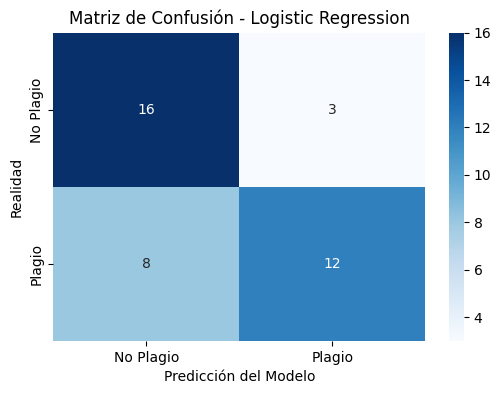

In [ ]:
# ============================================================
# Benchmark: Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Crear y entrenar el modelo
# ------------------------------------------------------------

if 'x_train' in locals():

    logistic_model = LogisticRegression(
        random_state=42,
        max_iter=1000
    )

    logistic_model.fit(x_train, y_train)

    print("============================================================")
    print("              BENCHMARK: LOGISTIC REGRESSION")
    print("============================================================\n")

    print("Modelo entrenado correctamente.")
    print(f"Número de features de entrada: {x_train.shape[1]}")

# ------------------------------------------------------------
# 2. Predicciones sobre el conjunto de validación
# ------------------------------------------------------------

if 'x_train' in locals():

    y_pred = logistic_model.predict(features_val)

    # Probabilidad de pertenecer a la clase 1: plagio
    y_pred_prob = logistic_model.predict_proba(features_val)[:, 1]

    # ------------------------------------------------------------
    # 3. Métricas principales
    # ------------------------------------------------------------

    accuracy = accuracy_score(resultado_val, y_pred)
    roc_auc = roc_auc_score(resultado_val, y_pred_prob)

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"AUC-ROC:  {roc_auc:.4f}")

    print("\n---------------- Classification Report ----------------\n")
    print(classification_report(
        resultado_val,
        y_pred,
        target_names=["No Plagio", "Plagio"]
    ))

    # ------------------------------------------------------------
    # 4. Matriz de confusión manual
    # ------------------------------------------------------------

    TP = 0
    TN = 0
    FP = 0
    FN = 0

    if hasattr(resultado_val, "values"):
        val_labels = resultado_val.values.flatten()
    else:
        val_labels = np.array(resultado_val).flatten()

    for i in range(len(y_pred)):
        if y_pred[i] == 1:
            if val_labels[i] == 1:
                TP += 1
            else:
                FP += 1
        else:
            if val_labels[i] == 0:
                TN += 1
            else:
                FN += 1

    print("\n---------------- Confusion Matrix Manual ----------------\n")
    print('-------------------------------------------')
    print('           ', 'label neg ', ' label pos')
    print(f'pred neg    {TN:<10} {FN:<10}')
    print(f'pred pos    {FP:<10} {TP:<10}')
    print('-------------------------------------------')

    # ------------------------------------------------------------
    # 5. Matriz de confusión visual
    # ------------------------------------------------------------

    cm = confusion_matrix(resultado_val, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["No Plagio", "Plagio"],
        yticklabels=["No Plagio", "Plagio"]
    )

    plt.title("Matriz de Confusión - Logistic Regression")
    plt.ylabel("Realidad")
    plt.xlabel("Predicción del Modelo")
    plt.show()

else:
    print("Error: x_train no existe. Ejecuta primero la celda donde preparas los datos.")

## Neural Network Model MLP Version 1 (Baseline)

In [ ]:
umbral = 0.8

In [ ]:
if 'x_train' in locals():
    input_dim = x_train.shape[1]

    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(input_dim,), name= "Entrada"),
        tf.keras.layers.Dense(16, activation='relu', name = "Capa1"),
        tf.keras.layers.Dense(1, activation='sigmoid', name= "Salida")
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.Precision(name='precision_Plagio',thresholds=umbral)]
    )

    model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa1 (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if 'x_train' in locals():
    history = model.fit(
        x_train,
        y_train,
        epochs=50,
        batch_size=5,
        validation_data=(features_val, resultado_val),
        verbose=1
    )

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.5910 - precision_Plagio: 0.9804 - val_loss: 0.5300 - val_precision_Plagio: 1.0000
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5548 - precision_Plagio: 0.9714 - val_loss: 0.5004 - val_precision_Plagio: 1.0000
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5334 - precision_Plagio: 0.9722 - val_loss: 0.4787 - val_precision_Plagio: 1.0000
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5158 - precision_Plagio: 0.9722 - val_loss: 0.4648 - val_precision_Plagio: 1.0000
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4971 - precision_Plagio: 0.9722 - val_loss: 0.4480 - val_precision_Plagio: 1.0000
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4801 - precision_Plagio: 0.9722 - val_loss: 0.4332 - val_precision_Plagio: 1.0000
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4693 - precision_Plagio: 0.9722 - val_loss: 0.4245 - val_precision_Plagio: 1.0000
Epoch

In [ ]:
model.save('plagiarism_prediction_model.keras')

## Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
              precision    recall  f1-score   support

Original - 0       0.67      0.94      0.78        17
  Plagio - 1       0.93      0.64      0.76        22

    accuracy                           0.77        39
   macro avg       0.80      0.79      0.77        39
weighted avg       0.82      0.77      0.77        39

AUC-ROC Score: 0.9572
(Un valor cercano a 1.0 indica alta capacidad para distinguir entre código humano e IA)



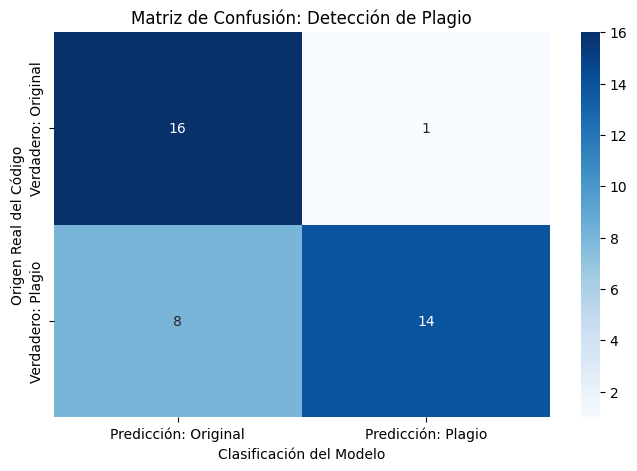

In [ ]:
if 'x_train' in locals():
    y_pred_prob = model.predict(features_test)
    y_pred = (y_pred_prob > umbral).astype(int)

    target_labels = ['Original - 0', 'Plagio - 1']
    print(classification_report(resultado_test, y_pred, target_names=target_labels))

    roc_val = roc_auc_score(resultado_test, y_pred_prob)
    print(f"AUC-ROC Score: {roc_val:.4f}")
    print("(Un valor cercano a 1.0 indica alta capacidad para distinguir entre código humano e IA)\n")

    plt.figure(figsize=(8, 5))

    cm = confusion_matrix(resultado_test, y_pred)
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Predicción: Original', 'Predicción: Plagio'],
                yticklabels=['Verdadero: Original', 'Verdadero: Plagio'])

    plt.title('Matriz de Confusión: Detección de Plagio')
    plt.xlabel('Clasificación del Modelo')
    plt.ylabel('Origen Real del Código')
    plt.show()
else:
  print("x_train data does not exist, reload cell")

---------------------------------------------------------
Variance explained by PC1: 81.64%
Variance explained by PC2: 8.31%
---------------------------------------------------------

Tabla de Importancia de Features (Loadings):


,PC1,PC2,Overall_Importance
Levenshtein Similarity,0.361382,0.077646,0.301472
ast_cosine_similarity,0.359483,0.029557,0.295927
length_file_diff,-0.358240,-0.025919,0.294610
function_count_diff,-0.348574,-0.110979,0.293786
mrt_oast_cosine_similarity,0.357414,0.009532,0.292575
cyclomatic_complexity_diff,-0.344989,-0.131039,0.292526
Token Similarity,0.318310,0.151145,0.272416
variable_count_diff,-0.319753,-0.032649,0.263750
comment_ratio_diff,-0.200023,0.968987,0.243790


/tmp/ipykernel_5556/1364123919.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Overall_Importance', y=loadings_sorted.index, data=loadings_sorted, palette='viridis')


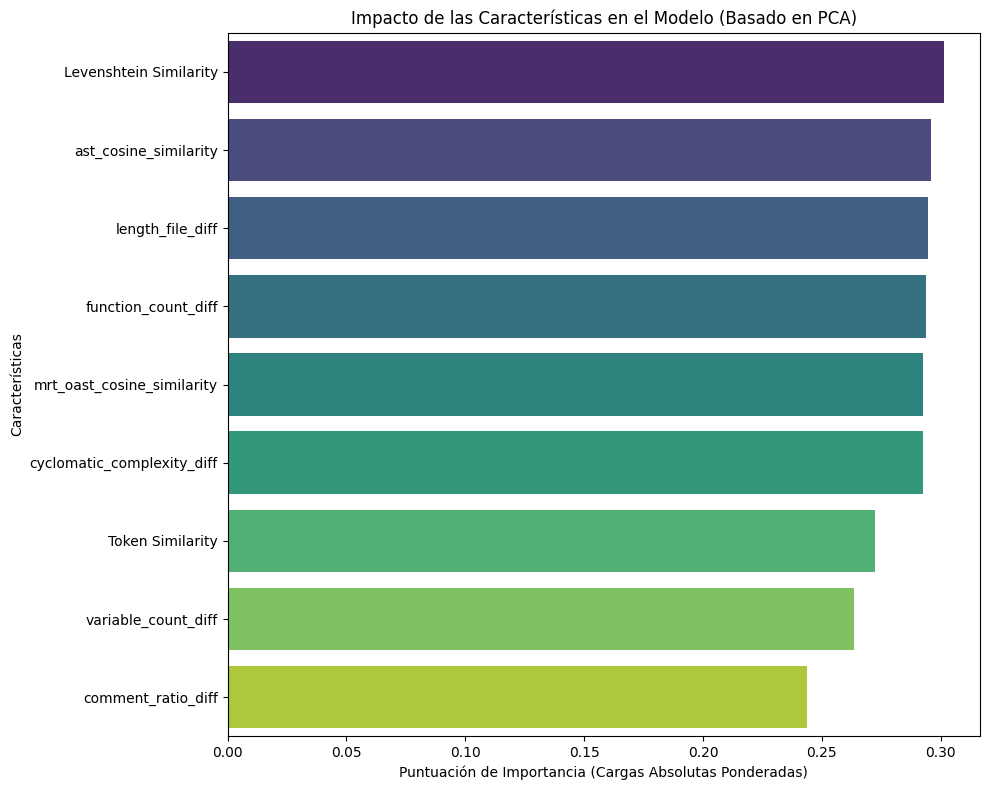

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if not df_integrated_features.empty:
    columns_to_drop = [
        'Label', 'AI_Model', 'File_1', 'File_2', 'AI_Model_Numeric',
        'Length File 1', 'Length File 2',
        'Function Count File 1', 'Function Count File 2',
        'Variable Count File 1', 'Variable Count File 2',
        'Cyclomatic Complexity File 1', 'Cyclomatic Complexity File 2',
        'Comment Ratio File 1', 'Comment Ratio File 2'
    ]
    existing_cols_to_drop = [col for col in columns_to_drop if col in df_integrated_features.columns]

    X = df_integrated_features.drop(existing_cols_to_drop, axis=1)
    X = X.select_dtypes(include=[np.number])
    feature_names = X.columns
    y = df_integrated_features['Label']

    # scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # fit pca
    pca = PCA(n_components=2)
    componentes_principales = pca.fit_transform(X_scaled)

    # pca.components_ shape is (n_components, n_features)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=feature_names
    )

    # Weighted Feature Importance
    # We take the absolute value of the loadings (since negative correlation still means high impact)
    # and weight them by the explained variance ratio of each principal component.
    explained_variance = pca.explained_variance_ratio_

    loadings['Overall_Importance'] = np.sum(np.abs(loadings.iloc[:, :2].values) * explained_variance, axis=1)

    # sort by highest importance
    loadings_sorted = loadings.sort_values(by='Overall_Importance', ascending=False)

    print("---------------------------------------------------------")
    print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
    print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%")
    print("---------------------------------------------------------\n")

    print("Tabla de Importancia de Features (Loadings):")
    display(loadings_sorted)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Overall_Importance', y=loadings_sorted.index, data=loadings_sorted, palette='viridis')
    plt.title('Impacto de las Características en el Modelo (Basado en PCA)')
    plt.xlabel('Puntuación de Importancia (Cargas Absolutas Ponderadas)')
    plt.ylabel('Características')
    plt.tight_layout()
    plt.show()

In [ ]:
# The code here is just kept to reference the authors of the code

# code from before 2020
# extremely unlikely to be AI, but may be plagiarized
not_ai_code = [
    "https://raw.githubusercontent.com/sarvasvkulpati/LinearRegression/refs/heads/master/LinearRegression.py",
    "https://raw.githubusercontent.com/barulalithb/Linear-Regression-from-Scratch/refs/heads/master/Linear%20Regression%20from%20scratch.py",
    "https://raw.githubusercontent.com/capt-calculator/linear_regression_from_scratch_py/refs/heads/master/linreg_scratch.py",
    "https://raw.githubusercontent.com/LarsNeR/LinearRegression/refs/heads/master/LinearRegression.py",
    "https://raw.githubusercontent.com/perborgen/KeepStraight/refs/heads/master/linear.py",
    "https://raw.githubusercontent.com/Jamaliela/LinearRegression_fromScratch/refs/heads/master/Linear_Regression.py",
    "https://raw.githubusercontent.com/ettore34/linearRegressionFromScratch-/refs/heads/master/test.py"
]

# code form 2025
# may or may not be AI
potentially_ai_code = [
    "https://raw.githubusercontent.com/0xHadyy/Linear-Regression-Scratch/refs/heads/master/Linear_Regression_Implementation.py",
    "https://raw.githubusercontent.com/l0stinfr0st/LinearRegressionScratch/refs/heads/main/LinearRegression.py",
    "https://raw.githubusercontent.com/sara-iskandar/linear-regression-scratch/refs/heads/main/linear_regression.py",
    "https://raw.githubusercontent.com/NishantSagar12345/LinearRegressionScratch/refs/heads/main/linear_regression_from_scratch.py",
    "https://raw.githubusercontent.com/VasuML07/LinearRegressionfromScratch/refs/heads/main/Linear.py",
    "https://raw.githubusercontent.com/OmarWill1/LinearRegression_Scratch/refs/heads/main/linearRegression.py",
    "https://raw.githubusercontent.com/ArayikKarapetyan/linear-regression-scratch/refs/heads/main/src/linear_regression.py",
    "https://raw.githubusercontent.com/NepSauce/linear-regression-scratch/refs/heads/main/linear_regression.py",
    "https://raw.githubusercontent.com/oscarbiggins/Linear_Regression_Scratch/refs/heads/main/linear_regression_scratch.py"
]

In [ ]:
def calculate_pair_features(file1_path, file2_path):
    tree1 = get_ast_tree(file1_path)
    tree2 = get_ast_tree(file2_path)
    if tree1 and tree2:
        ast_cos_sim = get_ast_cosine_similarity(tree1, tree2)
    else:
        ast_cos_sim = 0.0

    cc1 = get_cyclomatic_complexity(file1_path)
    cc2 = get_cyclomatic_complexity(file2_path)
    cc_diff = calculate_percentage_diff(cc1 , cc2)
    cr1 = calculate_comment_ratio(file1_path)
    cr2 = calculate_comment_ratio(file2_path)
    cr_diff = calculate_percentage_diff(cr1 , cr2)
    len1 = get_file_length(file1_path)
    len2 = get_file_length(file2_path)
    len_diff = calculate_percentage_diff(len1 , len2)
    func_count1, var_count1 = analyze_code_structure(file1_path)
    func_count2, var_count2 = analyze_code_structure(file2_path)
    func_diff = calculate_percentage_diff(func_count1 , func_count2)
    var_diff = calculate_percentage_diff(var_count1 , var_count2)
    lev_sim = get_levenshtein_similarity(file1_path, file2_path)
    tok_sim = get_token_similarity(file1_path, file2_path)

    # MRT-OAST Embeddings Check
    mrt_oast_sim = get_mrt_oast_cosine_similarity(file1_path, file2_path)

    return {
        'File_1_Path': file1_path,
        'File_2_Path': file2_path,
        'Token Similarity': tok_sim,
        'Levenshtein Similarity': lev_sim,
        'ast_cosine_similarity': ast_cos_sim,
        'length_file_diff': len_diff,
        'function_count_diff': func_diff,
        'variable_count_diff': var_diff,
        'cyclomatic_complexity_diff': cc_diff,
        'comment_ratio_diff': cr_diff,
        'mrt_oast_cosine_similarity': mrt_oast_sim
    }

def evaluate_validation_dataset(model_input, scaler, validation_df):
    if isinstance(model_input, str):
        model = tf.keras.models.load_model(model_input)
    else:
        model = model_input

    if hasattr(scaler, 'feature_names_in_'):
        expected_features = list(scaler.feature_names_in_)
    else:
        expected_features = [
            'Token Similarity', 'Levenshtein Similarity', 'ast_cosine_similarity',
            'length_file_diff', 'function_count_diff',
            'variable_count_diff', 'cyclomatic_complexity_diff', 'comment_ratio_diff',
            'mrt_oast_cosine_similarity'
        ]

    X_validation_ordered = validation_df[expected_features].copy()
    X_validation_scaled = scaler.transform(X_validation_ordered.values)
    predictions_prob = model.predict(X_validation_scaled)

    result_df = validation_df.copy()
    result_df['Plagiarism_Probability'] = predictions_prob
    result_df['Predicted_Class'] = (predictions_prob > umbral).astype(int)
    return result_df.sort_values(by='Plagiarism_Probability', ascending=False)

In [ ]:
def build_final_validation_dataset(validation_dir):
    all_files = []

    for root, dirs, files in os.walk(validation_dir):
        for file in files:
            if file.endswith('.py'):
                all_files.append(os.path.join(root, file))

    # gen all pairwise combos
    pairs = list(itertools.combinations(all_files, 2))

    validation_features = []

    for file1_path, file2_path in pairs:
        pair_data = calculate_pair_features(file1_path, file2_path)
        validation_features.append(pair_data)

    return pd.DataFrame(validation_features)

# Execute the extraction
validation_dir = "/content/final_validation_dataset"
df_real_world = build_final_validation_dataset(validation_dir)

display(df_real_world.head())

NameError: name 'itertools' is not defined

In [ ]:
import tensorflow as tf
import pandas as pd

def evaluate_validation_dataset(model_input, scaler, validation_df, umbral):
    """
    Wrapper function to load Keras model, scale validation dataframe,
    and append plagiarism predictions.

    Parameters:
    - model_input: File path to a saved model (str) OR a loaded tf.keras.Model object.
    - scaler: The StandardScaler instance previously fitted on the training data.
    - validation_df: The pandas DataFrame containing the extracted features.

    Returns:
    - A copy of the DataFrame sorted by Plagiarism_Probability in descending order.
    """

    # load from file or memory
    if isinstance(model_input, str):
        print(f"Loading model from {model_input}...")
        model = tf.keras.models.load_model(model_input)
    else:
        model = model_input

    # ask scaler exactly what features it learned on and in what order
    if hasattr(scaler, 'feature_names_in_'):
        expected_features = list(scaler.feature_names_in_)
    else:
        expected_features = [
            'Token Similarity', 'Levenshtein Similarity', 'ast_cosine_similarity',
            'length_file_diff', 'function_count_diff',
            'variable_count_diff', 'cyclomatic_complexity_diff', 'comment_ratio_diff'
        ]

    # check if scaler is expecting features we didn't calculate
    missing_features = [feat for feat in expected_features if feat not in validation_df.columns]
    if missing_features:
        raise ValueError(f"CRITICAL ERROR: Your scaler was trained on features that don't exist here: {missing_features}. You need to retrain your model strictly on the 9 relative features.")

    # reorder to exact order the scaler expects
    X_validation_ordered = validation_df[expected_features].copy()

    # scale
    X_validation_raw = validation_df[relative_features]
    # X_validation_scaled = scaler.transform(X_validation_raw)
    X_validation_scaled = scaler.transform(X_validation_ordered.values)

    # predict
    print("Generating predictions...")
    predictions_prob = model.predict(X_validation_scaled)

    # append results to a copy
    result_df = validation_df.copy()
    result_df['Plagiarism_Probability'] = predictions_prob
    result_df['Predicted_Class'] = (predictions_prob > umbral).astype(int)

    # sort by highest probability of plagiarism
    result_df_sorted = result_df.sort_values(by='Plagiarism_Probability', ascending=False)

    return result_df_sorted

In [ ]:
umbral = 0.8
final_results_df = evaluate_validation_dataset(model, scaler, df_real_world, umbral)

In [ ]:
# run from memory
final_results_df = evaluate_validation_dataset(model, scaler, df_real_world, umbral)

display(final_results_df)

In [ ]:
final_results_df['File_1'] = final_results_df['File_1_Path'].apply(lambda x: os.path.basename(x))
final_results_df['File_2'] = final_results_df['File_2_Path'].apply(lambda x: os.path.basename(x))
display(final_results_df.sort_values('Plagiarism_Probability', ascending=False))

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=final_results_df)